In [1]:
import numpy as np
import time
from scipy.optimize import minimize, differential_evolution
from scipy.stats import norm, qmc
from scipy.stats.qmc import LatinHypercube
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel, RationalQuadratic, DotProduct
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

import sys
sys.path.append('../pyJive/')

from utils import proputils as pu
import main
from names import GlobNames as gn
from names import ParamNames as pn

import io
import contextlib

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)




Run: 1
initial points: 1
Preparing GPs...
0
7.819460481457348
-8.0
1
-5.701054423645135
-5.719103621950675
2
-5.767006367384131
-17.010131905742927
3
9.935463669690005
-8.0
4
11.214859900965873
-5.059721049048107
5
-9.383001815485168
-9.383802317507786
6
-9.347357101471918
-9.380674899553867
7
16.116984568223703
-8.0
8
6.1033700827079365
-4.932240593365348
9
-12.80825545858407
-12.808489738204718
10
-6.9062201129142275
-7.01372774154076
11
19.168132170437993
-8.0
12
1.7536963607583205
-3.0447621049405216
13
-14.608408639137837
-14.610410598399955
14
-4.395796560910224
-4.489046800430327
15
19.999983672306804
-8.0
16
19.91178390226593
-1.7020181244945034
17
-17.330787797294498
-17.33165702063146
[ 12.5     17.5      5.75     3.75   907.2491 179.8671 636.7873 141.8271
 407.9442  94.0559 198.7897  29.5157]
4512.262399077008
0.24797042631758628


Iteration 1
Fitting GPs...
Finding next point...
mu: [0.], sigma: [0.00447214], threshold: -0.24797042631758628, prob: [0.]

mu: 0.0, sigma: 1.41

KeyboardInterrupt: 

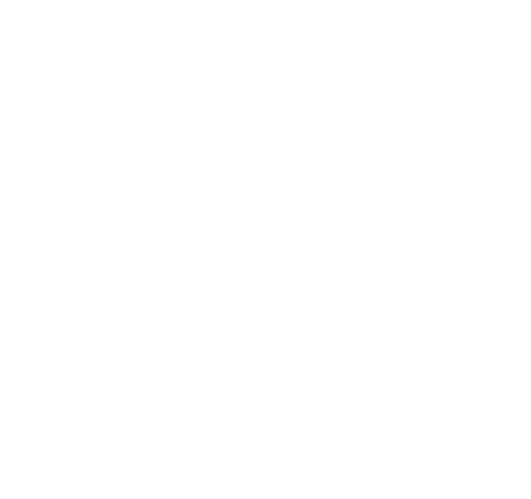

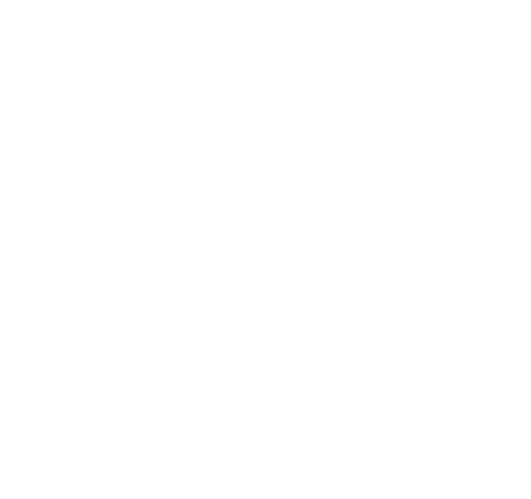

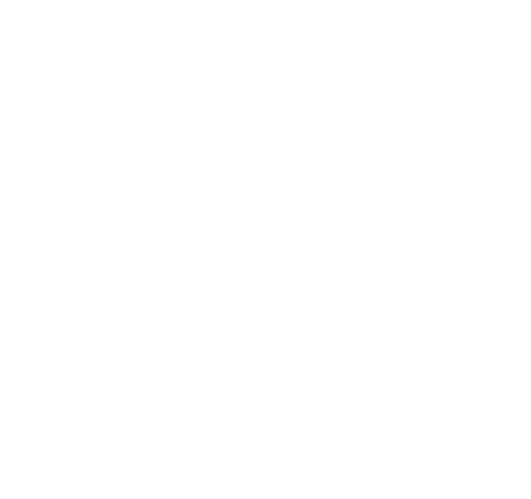

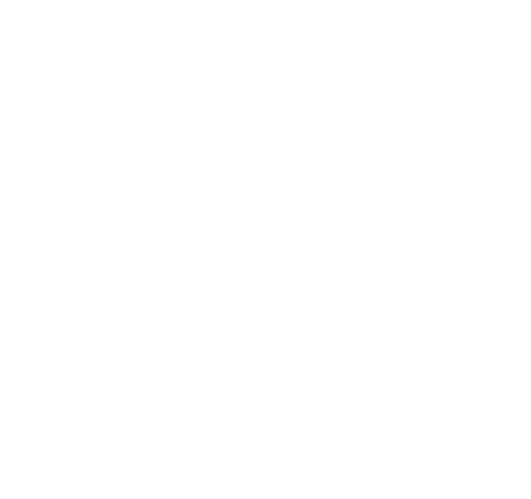

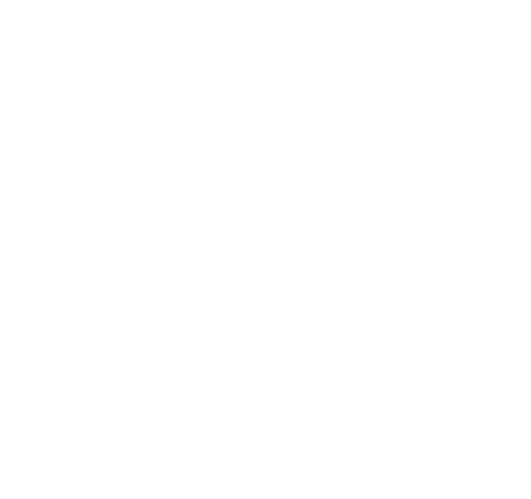

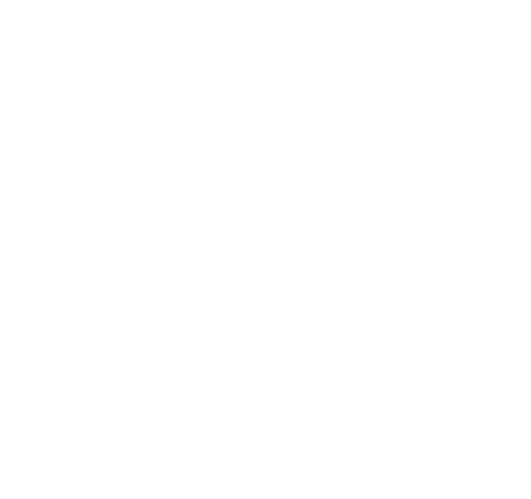

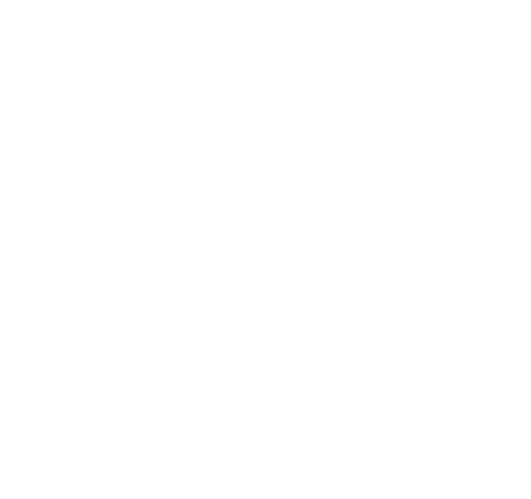

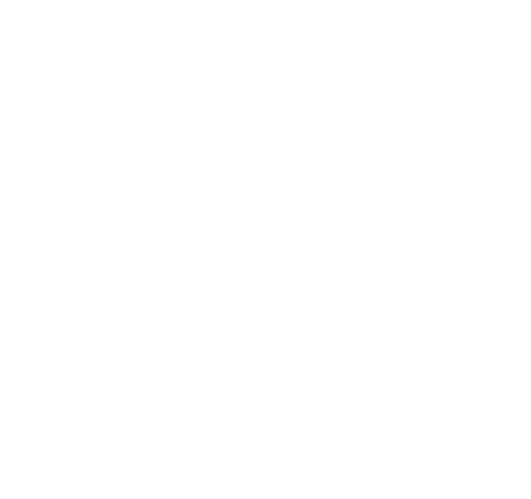

In [7]:
def update_geom_file(geom_path, coords, node_idx):
    
    x_coords = coords[0::2]
    y_coords = coords[1::2]

    # Read the .geom file
    with open(geom_path, 'r') as file:
        lines = file.readlines()
        
    j = 0 
    for i in range(len(lines)):
        if lines[i][0] in node_idx:
            lines[i] = f'{i-1} {x_coords[j]} {y_coords[j]}\n' 
            j+=1
        if lines[i][0] == 'm':
            break
            
    with open(geom_path, 'w') as file:
        file.writelines(lines)
            
def parse_geometry_file(file_path, areas, N):
    # Read the file
    with open(file_path, "r") as file:
        lines = file.readlines()

    # Identify split point (between nodes and elements)
    split_index = None
    for i, line in enumerate(lines):
        if line.strip() == "":  # Assuming empty line separates nodes and elements
            split_index = i
            break

    # Read node data (top part)
    nodes_data = []
    for line in lines[:split_index]:
        parts = line.strip().split()
        if len(parts) == 3:  # Expecting index, x, y
            node_index, x, y = map(float, parts)
            nodes_data.append((int(node_index), x, y))

    # Read element data (bottom part)
    elements_data = []
    for line in lines[split_index + 1:]:
        parts = line.strip().split()
        if len(parts) == 4:  # Expecting node_1, node_2, number, cross_section
            node_1, node_2, number, cross_section = map(float, parts)
            elements_data.append((int(node_1), int(node_2), int(number), int(cross_section)))

    # Create dictionaries for easy access
    nodes_dict = {node[0]: {"x": node[1], "y": node[2]} for node in nodes_data}
    elements_dict = {}

    # Compute element lengths and store data
    for i, elem in enumerate(elements_data):
        node_1, node_2, cross_section = elem[0], elem[1], elem[3]

        # Get coordinates of the two nodes
        x1, y1 = nodes_dict[node_1]["x"], nodes_dict[node_1]["y"]
        x2, y2 = nodes_dict[node_2]["x"], nodes_dict[node_2]["y"]

        # Compute properties
        length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        area = areas[elem[3]]
        sigma = N[i][0] / area
        sigma_buc = 4 * 1e4 * area / length**2

        # Store element data with computed length
        elements_dict[i] = {
            "node_1": node_1,
            "node_2": node_2,
            "area": area,
            "length": length,
            "sigma": sigma,
            "sigma_buc": sigma_buc,
            
        }

    return nodes_dict, elements_dict

def get_weight(elements_dict):
    weight = 0
    for elem_id, elem in elements_dict.items():
        weight += 0.1 * elem['length'] * elem['area']
    return weight
        
def compute_constraint_1(elements_dict):
    constr_value = 1
    for elem_id, elem in elements_dict.items():
        constr_stress = abs(elem['sigma']) / 25
        constr_buc = elem['sigma'] / -elem['sigma_buc']
        constr_value *= max(1, constr_stress, constr_buc)
    return constr_value

def compute_constraint_2(elements_dict):
    constr_list = []
    for elem_id, elem in elements_dict.items():
        constr_stress = abs(elem['sigma']) / 25
        constr_buc = elem['sigma'] / -elem['sigma_buc']
        constr_list.append(constr_stress)
        constr_list.append(constr_buc)
        constr_value = max(constr_list)
        # print(elem_id)
        # print(constr_stress)
        # print(constr_buc)
        # print(constr_value)
    return constr_value

def compute_constraint_3(elements_dict):
    constr_list = []
    for elem_id, elem in elements_dict.items():
        constr_stress = (25 - abs(elem['sigma'])) / 25
        constr_buc = (-elem['sigma_buc'] - elem['sigma']) / -elem['sigma_buc']
        constr_list.append(constr_stress)
        constr_list.append(constr_buc)
        constr_value = min(constr_list)
        # print(elem_id)
        # print(constr_stress)
        # print(constr_buc)
        # print(constr_value)
    return constr_value

def compute_constraint_4(elements_dict):
    constr_list = []
    for elem_id, elem in elements_dict.items():
        constr_stress = (25 - abs(elem['sigma'])) / 25
        constr_buc = (-elem['sigma_buc'] - elem['sigma']) / -elem['sigma_buc']
        constr_list.append(constr_stress)
        constr_list.append(constr_buc)
        constr_value = 0.8 * min(constr_list) + 0.2 * np.mean(constr_list)
        print(elem_id)
        print(elem['sigma'])
        print(-elem['sigma_buc'])
    return constr_value

def finite_element_solver(x):
    area = x[:4]
    coords = x[4:]
    node_idx = ['2', '4', '6', '8']
    
    update_geom_file('cantilever.geom', coords, node_idx)
    
    # Load properties
    props = pu.parse_file('cantilever.pro')
    
    # Update cross-section area
    props['model']['truss']['area'] = area
    
    # Run FEM simulation
    with contextlib.redirect_stdout(io.StringIO()):
        globdat = main.jive(props)
    
    N = globdat['tables']['stress'][0].get_all_values()[::2]
    
    nodes_dict, elements_dict = parse_geometry_file('cantilever.geom', area, N)
    
    weight = get_weight(elements_dict)
    
    # constr_value = compute_constraint_1(elements_dict)
    constr_value = compute_constraint_4(elements_dict)
    
    # print(elements_dict)

    return weight, constr_value

def feasibility_probability(x, gp, threshold):
    mu, sigma = gp.predict(x.reshape(1, -1), return_std=True)
    prob = norm.cdf((threshold - mu) / (sigma))
    
    print(f"mu: {mu}, sigma: {sigma}, threshold: {threshold}, prob: {prob}")
    
    return prob

def EI(x, gp_Y, gp_constr, Y_samples, threshold, xi, best_y):
    mu, sigma = gp_Y.predict(x.reshape(1, -1), return_std=True)
    mu, sigma = mu[0], sigma[0]
    best = best_y
    
    z = (best - mu - xi) / (sigma)
    ei = (best - mu - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    
    prob = 1 - feasibility_probability(x, gp_constr, threshold)
    
    print('')
    print(f"mu: {mu}, sigma: {sigma}, best: {best}, xi: {xi}, z: {z}, ei: {ei}, prob: {prob}, EI: {ei * prob}")

    return -ei * prob

def adaptive_xi_linear(iteration, max_iterations, xi_max=0, xi_min=0):
    return xi_max - (xi_max - xi_min) * (iteration / max_iterations)

def generate_lhs_samples(num_samples, bounds):
    # Extract dimensions from bounds
    dimensions = len(bounds)

    # Initialize LHS sampler
    sampler = LatinHypercube(d=dimensions)

    # Generate LHS points in [0, 1]^D space
    lhs_points = sampler.random(n=num_samples)

    # Scale points to the specified bounds
    bounds = np.array(bounds)
    lower_bounds = bounds[:, 0]
    upper_bounds = bounds[:, 1]

    # Scale points to the [lower_bounds, upper_bounds] range
    scaled_points = lower_bounds + (upper_bounds - lower_bounds) * lhs_points

    return scaled_points


def bayesian_optimization(n_iter=1000, improvement_threshold=1e-3, patience = 50):  
    
    n_init = 1
    n_dim = 12
    
    print(f'initial points: {n_init}')
    print('Preparing GPs...')
    
    bounds_unscaled = np.array([[2.00, 21.75],
                                [2.00, 21.75],
                                [2.00, 21.75],
                                [2.00, 21.75],
                                [775, 1225],
                                [-225, 245],
                                [525, 975],
                                [-225, 245],
                                [275, 725],
                                [-225, 245],
                                [25, 475],
                                [-225, 245],
                               ])
    
    # bounds_unscaled = np.array([[10, 15],
    #                             [15, 20],
    #                             [5, 6],
    #                             [3, 4],
    #                             [850, 950],
    #                             [150, 200],
    #                             [600, 700],
    #                             [100, 200],
    #                             [350, 450],
    #                             [50, 200],
    #                             [150, 250],
    #                             [-50, 100],
    #                            ])
    
    X_samples_unscaled = generate_lhs_samples(num_samples=n_init, bounds=bounds_unscaled)
    
    #
    x_feasible = [21.75, 21.75, 21.75, 21.75, 1000, 0, 750, 0, 500, 0, 250, 0]
    x_cspso = [12.5, 17.5, 5.75, 3.75, 907.2491, 179.8671, 636.7873, 141.8271, 407.9442, 94.0559, 198.7897, 29.5157]
    X_samples_unscaled[0] = np.array(x_cspso) 
    #
    
    # with contextlib.redirect_stdout(io.StringIO()):
    output = np.array([finite_element_solver(x) for x in X_samples_unscaled])
    
    Y_samples_unscaled = output[:, 0]
    constr_samples_unscaled = output[:, 1]
    threshold_unscaled = 0
    
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()
    constr_scaler = StandardScaler()
    
    X_samples = input_scaler.fit_transform(X_samples_unscaled)
    Y_samples = output_scaler.fit_transform(Y_samples_unscaled.reshape(-1, 1)).flatten()
    constr_samples = constr_scaler.fit_transform(constr_samples_unscaled.reshape(-1, 1)).flatten()
    
    print(X_samples_unscaled[0])
    print(Y_samples_unscaled[0])
    print(constr_samples_unscaled[0])
    
    bounds = input_scaler.transform(bounds_unscaled.T).T
    threshold = constr_scaler.transform(np.array(threshold_unscaled).reshape(-1, 1))[0, 0]
    
    kernel_Y = Matern(length_scale=[10] * 12, nu=2.5, length_scale_bounds=(0.1, 1000)) + RBF(length_scale=10)
    # kernel_constr = 1.0 * Matern(length_scale=[10] * 12, nu=1.5, length_scale_bounds=(0.1, 1000)) + RBF(length_scale=10) + 0.5* RBF(length_scale=[10] * 12, length_scale_bounds=(0.1, 1000)) + RBF(length_scale=10)
    kernel_constr = 1.0*Matern(length_scale=[1]*12, nu=3.5) + 0.5*RBF(length_scale=[1]*12)
    # kernel_constr = RBF(length_scale=[1]*12)
    # kernel_constr = (1.0 * Matern(length_scale=[1.0] * n_dim, nu=1.5) + WhiteKernel(noise_level=1e-6))
    # kernel_constr = (1.0 * Matern(length_scale=[1.0] * n_dim, nu=2.5) + 0.5 * RBF(length_scale=[2.0] * n_dim) +  WhiteKernel(noise_level=1e-6))
    
    gp_Y = GaussianProcessRegressor(kernel=kernel_Y, alpha=0)
    gp_constr = GaussianProcessRegressor(kernel=kernel_constr, alpha=0)
    
    valid_idx = np.where(constr_samples >= threshold)[0]
    best_y = np.min(Y_samples[valid_idx])
    best_x = X_samples[valid_idx][np.argmin(Y_samples[valid_idx])]
    
    y_next_list = []
    no_improvement_count = 0  # Counter for iterations without improvement
    
    for iteration in range(n_iter):
            
        print('')
        print('')
        print(f'Iteration {iteration + 1}') 
        print('Fitting GPs...')
        
        if iteration % 5 == 0.312312312:
            print("Optimizing hyperparameters...")
            gp_Y.optimizer = 'fmin_l_bfgs_b'  # Enable optimization
            gp_constr.optimizer = 'fmin_l_bfgs_b'  # Enable optimization
            gp_Y.fit(X_samples, Y_samples)
            gp_constr.fit(X_samples, constr_samples)
        else:
            # optimized_kernel_Y = gp_Y.kernel_
            # optimized_kernel_constr = gp_constr.kernel_
            # gp_Y = GaussianProcessRegressor(kernel=optimized_kernel_Y, alpha=0, optimizer=None)
            # gp_constr = GaussianProcessRegressor(kernel=optimized_kernel_constr, alpha=0, optimizer=None)
            gp_Y.fit(X_samples, Y_samples)
            gp_constr.fit(X_samples, constr_samples)
            print('Finding next point...')
        
        # Use adaptive xi every other iteration
        # if iteration % 2 == 0:
        xi = adaptive_xi_linear(iteration, n_iter, xi_max=3, xi_min=3)
        # else:
        #     xi = 0  # Or some other fixed value for exploitation
        
        def acquisition(x):
            return EI(x, gp_Y, gp_constr, Y_samples, threshold, xi, best_y)
        
        with contextlib.redirect_stdout(io.StringIO()):
             result = differential_evolution(lambda x: acquisition(x), bounds=bounds, strategy='best1bin', popsize=5, maxiter=10, tol=1e-6, polish=True)
            # result = minimize(lambda x: acquisition(x), 
                    # x0=np.random.uniform(bounds[:, 0], bounds[:, 1]), 
                    # bounds=bounds, 
                    # method='L-BFGS-B', 
                    # options={'maxiter': 100, 'disp': False})
        x_next = result.x
        
        x_next_unscaled = input_scaler.inverse_transform(x_next.reshape(-1, n_dim))[0]
        
        #
        # x_next_unscaled = np.array([12.5, 17.5, 5.75, 3.75, 907.2491, 179.8671, 636.7873, 141.8271, 407.9442, 94.0559, 198.7897, 29.5157])
        # x_next = input_scaler.transform(x_next_unscaled.reshape(-1, n_dim))[0]
        #
        
        with contextlib.redirect_stdout(io.StringIO()):
            output_next_unscaled = finite_element_solver(x_next_unscaled)
        y_next_unscaled = output_next_unscaled[0]
        constr_next_unscaled = output_next_unscaled[1]
        
        acquisition(x_next)
        y_next = output_scaler.transform(y_next_unscaled.reshape(-1, 1))[0]
        constr_next = constr_scaler.transform(constr_next_unscaled.reshape(-1, 1))[0]
        
        X_samples = np.vstack((X_samples, x_next))
        Y_samples = np.append(Y_samples, y_next)        
        constr_samples = np.append(constr_samples, constr_next)
        
        valid_idx = np.where(constr_samples >= threshold)[0]
        best_y = np.min(Y_samples[valid_idx])
        y_next_list.append(y_next_unscaled)
        best_y_unscaled = output_scaler.inverse_transform(best_y.reshape(-1, 1))[0][0]
        
        if y_next_unscaled < best_y_unscaled - improvement_threshold:
            no_improvement_count = 0  # Reset counter on improvement
        else:
            no_improvement_count += 1  # Increment counter if no improvement

        if no_improvement_count >= patience:
            print(f"Stopping early due to no improvement for {patience} iterations.")
            break
        
        print('')
        # print("Optimized Kernel Y:", gp_Y.kernel_)
        # print("Optimized Kernel constr:", gp_constr.kernel_)
        print('')
        print(f'time: {time.time() - start_time}')
        print(f'variables: {x_next_unscaled}')
        print(f'best weight: {best_y_unscaled}')
        print(f'weight: {y_next_unscaled}')
        print(f'constr: {constr_next_unscaled}')
        print(f'constr: {constr_next}')
        print('')
        
    plt.plot(y_next_list, label='Next y value')
    plt.axhline(y=best_y_unscaled, color='r', linestyle='--', label=f'Best weight: {best_y_unscaled:.2f}')
    plt.xlabel('Iteration')
    plt.ylabel('Weight')
    plt.title('Optimization Progress')
    plt.legend()


    valid_idx = np.where(constr_samples >= threshold)[0]
    best_idx = valid_idx[np.argmin(Y_samples[valid_idx])]
    best_x_unscaled = input_scaler.inverse_transform(X_samples[best_idx].reshape(-1, n_dim))[0]
    best_y_unscaled = output_scaler.inverse_transform(Y_samples[best_idx].reshape(-1, 1))[0, 0]
    best_constr_unscaled = constr_scaler.inverse_transform(constr_samples[best_idx].reshape(-1, 1))[0, 0]

    # Add frequencies as text below the legend
    constr_text = f"Constr: {best_constr_unscaled:.2f}"
    plt.text(0.5, -0.15, constr_text, ha='center', va='center', transform=plt.gca().transAxes, fontsize=8)
    
    plt.show()
    
    return best_x_unscaled, best_y_unscaled, best_constr_unscaled


for i in range(1):
    print(f'Run: {i+1}')
    
    start_time = time.time()
    variables, weight, constr = bayesian_optimization()
    end_time = time.time()

    print('Best values')
    print(f'time: {end_time - start_time}')
    print(f'variables: {variables}')
    print(f'area: {area}')
    print(f'weight: {weight}')
    print(f'constr: {constr}')
    print('')
